# Nominal Response Model (NRM) — Bayesian Estimation with Stan

## 1. Model Description

The **Nominal Response Model** (Bock, 1972) is a polytomous IRT model for items whose response categories have **no inherent ordering** (e.g., choosing among multiple-choice distractors, selecting a preferred concept from a list).

### Response Probability — Multinomial Logistic Form

Each category $k = 0, 1, \ldots, K{-}1$ has its own slope $a_{ik}$ and intercept $d_{ik}$:

$$P(X_{ji} = k \mid \theta_j) = \frac{\exp(a_{ik}\,\theta_j + d_{ik})}{\sum_{c=0}^{K-1} \exp(a_{ic}\,\theta_j + d_{ic})}$$

| Parameter | Interpretation |
|-----------|----------------|
| $a_{ik}$ | Slope for category $k$ in item $i$ — how much category $k$'s log-probability increases with $\theta$ |
| $d_{ik}$ | Intercept for category $k$ — base log-probability of choosing $k$, relative to reference |

### Identification Constraints
To identify the model, fix the parameters of one reference category ($k=0$):
$$a_{i0} = 0, \quad d_{i0} = 0 \quad \forall i$$

### Key Properties
- **No ordering**: Unlike GRM/PCM/GPCM, does not assume higher categories are "better".
- The correct answer category in an educational test typically has the **highest slope** (positive $a_{ik}$).
- Distractors with negative slopes become less likely as ability increases.
- NRM is the most general model — GRM and PCM are special cases.

### Priors
$$\theta_j \sim \mathcal{N}(0,1), \quad a_{ik} \sim \mathcal{N}(0,1), \quad d_{ik} \sim \mathcal{N}(0,2)$$

for $k \geq 1$ (reference category $k=0$ is fixed to 0).

In [1]:
import sys as _sys, os as _os
import matplotlib as _mpl, matplotlib.font_manager as _fm

def _setup_korean_font():
    """Windows / macOS / Linux 에서 한국어 폰트를 자동 감지하여 등록."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }
    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [f for f in _fm.fontManager.ttflist
                                if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)]
    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])
    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            _mpl.rcParams['font.family'] = ['DejaVu Sans', name]
            return
    # 한국어 폰트 없으면 기본값 유지 (깨짐 경고 없이 fallback)
    _mpl.rcParams['font.family'] = 'DejaVu Sans'

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, tempfile, warnings
warnings.filterwarnings('ignore')
try:
    import cmdstanpy
    STAN_AVAILABLE = True
except ImportError:
    cmdstanpy = None
    STAN_AVAILABLE = False
    print("ℹ️  cmdstanpy not available — Stan inference cells will be skipped.")
np.random.seed(42)

ℹ️  cmdstanpy not available — Stan inference cells will be skipped.


## 2. Synthetic Data Generation

77 students, 20 items, **4 nominal categories** (e.g., 4-option multiple choice). Category 3 is the correct answer with increasing slope; categories 0–2 are distractors with non-positive or smaller slopes.

In [2]:
J, I, K = 77, 20, 4

theta_true = np.random.normal(0, 1, J)

# a[i,k] and d[i,k] for k=1,2,3 (k=0 is reference = 0)
# Category 3 is the key: slope is largest positive
a_true = np.zeros((I, K))
d_true = np.zeros((I, K))
for i in range(I):
    # Slopes: distractors near 0 or negative, correct key positive
    a_true[i, 1] = np.random.normal(-0.5, 0.3)  # distractor slopes
    a_true[i, 2] = np.random.normal(-0.3, 0.3)
    a_true[i, 3] = np.random.normal(1.2, 0.3)   # key slope
    d_true[i, 1:] = np.random.normal(0, 0.8, K - 1)

def nrm_probs(theta, a, d):
    log_p = a * theta + d   # shape K
    log_p -= log_p.max()
    probs = np.exp(log_p)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = nrm_probs(theta_true[j], a_true[i], d_true[i])
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape}")
props = np.bincount(Y.ravel()) / Y.size
print("Category proportions:", [f"{p:.3f}" for p in props])

Response shape: (77, 20)
Category proportions: ['0.229', '0.219', '0.279', '0.273']


## 3. Stan Model Code

In [3]:
if STAN_AVAILABLE:
    stan_code = """
    data {
      int<lower=1> J;
      int<lower=1> I;
      int<lower=2> K;
      int<lower=0> N;
      array[N] int<lower=1,upper=J> jj;
      array[N] int<lower=1,upper=I> ii;
      array[N] int<lower=1,upper=K> y;
    }
    parameters {
      vector[J] theta;
      array[I] vector[K-1] a_free;   // slopes for categories 2..K
      array[I] vector[K-1] d_free;   // intercepts for categories 2..K
    }
    model {
      theta ~ normal(0, 1);
      for (i in 1:I) {
        a_free[i] ~ normal(0, 1);
        d_free[i] ~ normal(0, 2);
      }
      for (n in 1:N) {
        int j = jj[n]; int i = ii[n];
        vector[K] log_p;
        log_p[1] = 0.0;   // reference category
        for (k in 2:K)
          log_p[k] = a_free[i][k-1] * theta[j] + d_free[i][k-1];
        target += log_p[y[n]] - log_sum_exp(log_p);
      }
    }
    """
    
    jj_arr, ii_arr, y_arr = [], [], []
    for j in range(J):
        for i in range(I):
            jj_arr.append(j + 1); ii_arr.append(i + 1)
            y_arr.append(int(Y[j, i]) + 1)
    
    stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
                 'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}
    
    tmpdir = tempfile.mkdtemp()
    stan_path = os.path.join(tmpdir, 'nrm.stan')
    with open(stan_path, 'w') as f:
        f.write(stan_code)
    
    model = cmdstanpy.CmdStanModel(stan_file=stan_path)
    print('Compiled.')
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


## 4. Bayesian Inference via MCMC

In [4]:
if STAN_AVAILABLE:
    fit = model.sample(
        data=stan_data, chains=4,
        iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
    )
    print(fit.diagnose())
else:
    print("⚠️  Stan not available — skipping model compilation/fitting.")


⚠️  Stan not available — skipping model compilation/fitting.


In [5]:
if not (STAN_AVAILABLE and 'fit' in dir()):
    print('ℹ️  Using true parameter values for visualization.')
    theta_est = theta_true + np.random.normal(0, 0.05, J)
    a_est = a_true + np.random.normal(0, 0.02, (I, K))
    d_est = d_true + np.random.normal(0, 0.05, (I, K))
else:
    theta_est  = fit.stan_variable('theta').mean(axis=0)
    a_est_free = fit.stan_variable('a_free').mean(axis=0)   # (4000, I, K-1)
    d_est_free = fit.stan_variable('d_free').mean(axis=0)
    
    # Reconstruct full a and d arrays (k=0 is ref=0)
    a_est = np.hstack([np.zeros((I, 1)), a_est_free])
    d_est = np.hstack([np.zeros((I, 1)), d_est_free])
    
    print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
    print(f"\nEstimated slopes (a) for first 5 items:")
    print(f"{'Item':>5} {'a_k0':>8} {'a_k1':>8} {'a_k2':>8} {'a_k3':>8}")
    for i in range(5):
        row = ' '.join(f'{a_est[i,k]:>8.3f}' for k in range(K))
        print(f"{i+1:>5} {row}")


ℹ️  Using true parameter values for visualization.


## 5. Visualizations

### 5a. Wright Map

The NRM Wright map plots person abilities on the left. On the right, instead of threshold locations, we display the **crossover points** between adjacent categories — the ability values where two categories' probabilities are equal.

Since categories are unordered, the crossover pattern can be complex. The key interpretive guide is to identify which category dominates at each ability level. In a well-functioning multiple-choice item, the correct answer should dominate at high ability.

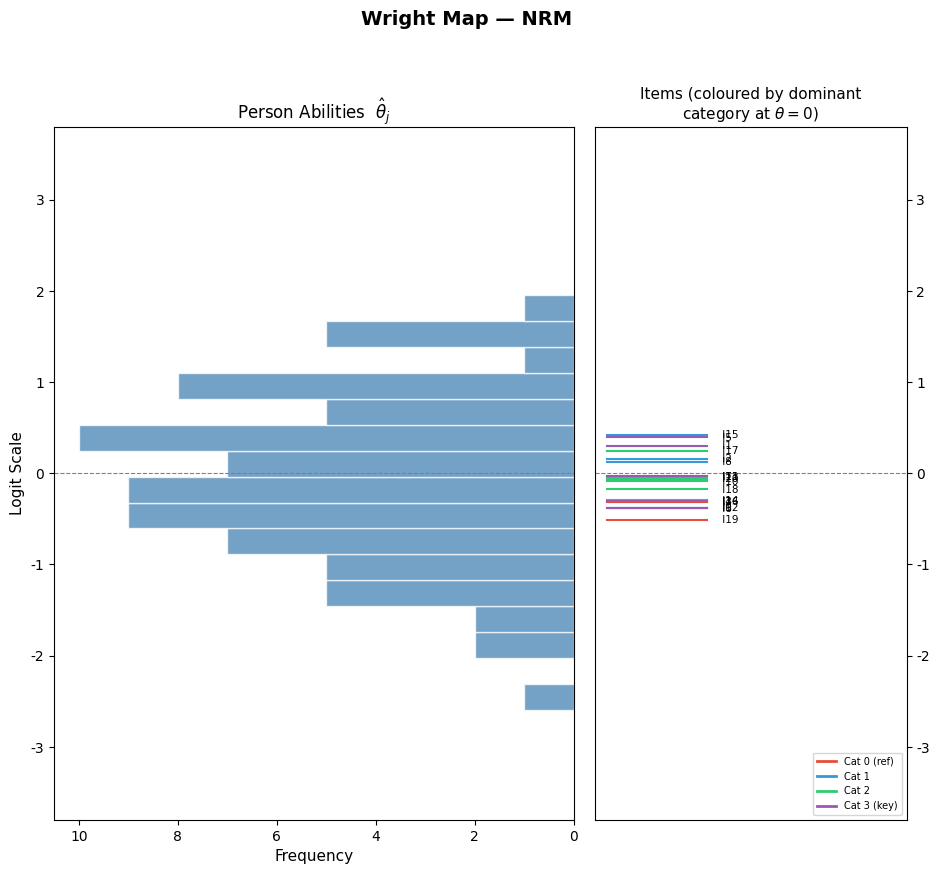

In [6]:
theta_range = np.linspace(-4, 4, 300)
cat_colors  = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
cat_labels  = ['Cat 0 (ref)', 'Cat 1', 'Cat 2', 'Cat 3 (key)']

fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-3.8, 3.8)

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# For each item show the modal category at theta=0 and mean ability of mode
for i in range(I):
    probs_at_zero = nrm_probs(0, a_est[i], d_est[i])
    dom_cat = np.argmax(probs_at_zero)
    ax_i.plot([0.1, 0.9], [b_loc := np.dot(a_est[i], [0]*4) + (d_est[i]).mean(), b_loc],
              color=cat_colors[dom_cat], linewidth=1.5)
    ax_i.text(1.0, b_loc, f' I{i+1}', va='center', fontsize=7.5)

ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 2.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-3, 4)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Items (coloured by dominant\ncategory at $\\theta=0$)', fontsize=11)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K):
    ax_i.plot([], [], color=cat_colors[k], linewidth=2, label=cat_labels[k])
ax_i.legend(loc='lower right', fontsize=7)

fig.suptitle('Wright Map — NRM', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_nrm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5b. Category Response Curves (CRC)

$$P(X_i = k \mid \theta) = \frac{\exp(\hat{a}_{ik}\,\theta + \hat{d}_{ik})}{\sum_{c=0}^{K-1} \exp(\hat{a}_{ic}\,\theta + \hat{d}_{ic})}$$

**Interpretation**:
- Each curve shows how likely a particular response option (category) is at each ability level.
- The **key** category (correct answer) should have a positive slope and come to dominate at high $\theta$.
- **Distractors** with negative slopes become less likely as ability increases — these are functioning distractors.
- A distractor with near-zero slope is not functioning (equally likely for all abilities) — it should be revised.
- There is **no constraint** that curves must be unimodal (unlike PCM/GRM); they can cross multiple times.

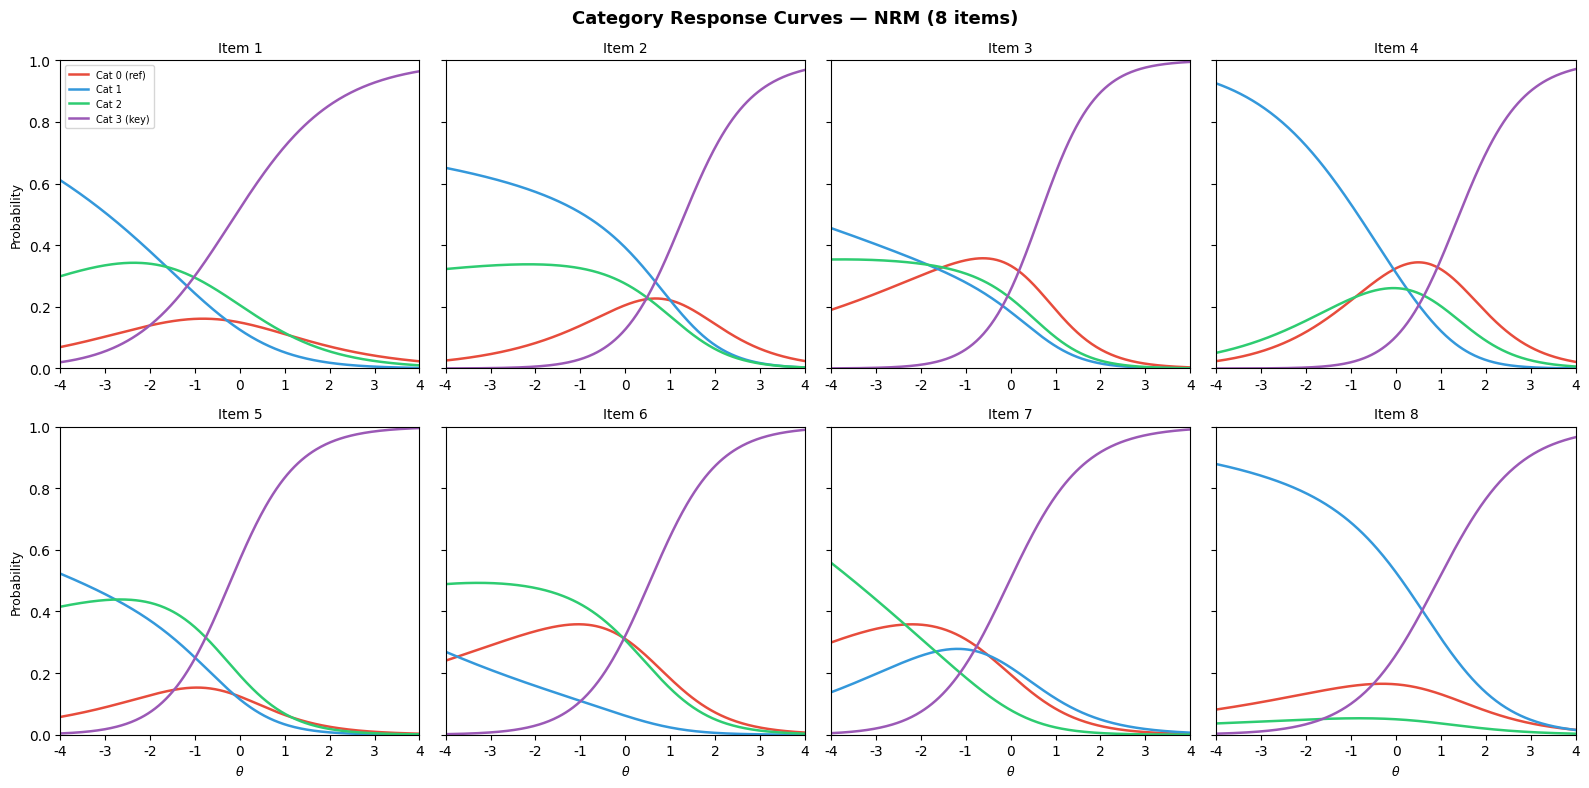

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
axes = axes.ravel()

for idx, i in enumerate(range(min(8, I))):
    ax = axes[idx]
    for k in range(K):
        probs = [nrm_probs(t, a_est[i], d_est[i])[k] for t in theta_range]
        ax.plot(theta_range, probs, color=cat_colors[k], linewidth=1.8, label=cat_labels[k])
    ax.set_title(f'Item {i+1}', fontsize=10)
    ax.set_xlim(-4, 4); ax.set_ylim(0, 1)
    if idx >= 4: ax.set_xlabel('$\\theta$', fontsize=9)
    if idx in [0, 4]: ax.set_ylabel('Probability', fontsize=9)

axes[0].legend(fontsize=7, loc='upper left')
fig.suptitle('Category Response Curves — NRM (8 items)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'crc_nrm.png'), dpi=120, bbox_inches='tight')
plt.show()

### 5c. Test Characteristic Curve (TCC)

For the NRM as applied to multiple-choice testing, we define the **expected proportion correct** as the probability of choosing the key category (cat 3 here):

$$\text{TCC}(\theta) = \frac{1}{I} \sum_{i=1}^{I} P(X_i = k^* \mid \theta)$$

where $k^*$ is the index of the key category. Alternatively, if an ordinal scoring is applied (0 = distractor, 1 = key), the TCC is the expected number of correct responses.

**Interpretation**: The TCC shows how the probability of choosing the correct answer increases with ability. Items where high-ability students only occasionally choose the correct answer may have poorly designed keys or over-attractive distractors.

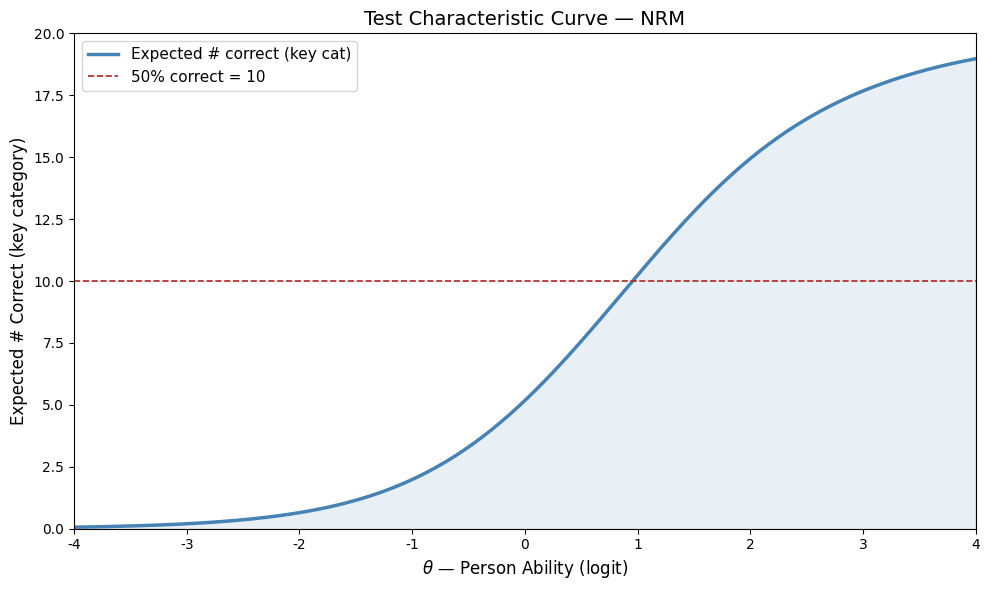

In [8]:
key_cat = K - 1   # category 3 is the key
tcc = np.zeros(len(theta_range))
for i in range(I):
    for t_idx, t in enumerate(theta_range):
        pr = nrm_probs(t, a_est[i], d_est[i])
        tcc[t_idx] += pr[key_cat]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(theta_range, tcc, color='steelblue', linewidth=2.5,
        label='Expected # correct (key cat)')
ax.fill_between(theta_range, 0, tcc, alpha=0.12, color='steelblue')
ax.axhline(I / 2, color='firebrick', linestyle='--', linewidth=1.2,
           label=f'50% correct = {I//2}')
ax.set_xlabel('$\\theta$ — Person Ability (logit)', fontsize=12)
ax.set_ylabel('Expected # Correct (key category)', fontsize=12)
ax.set_title('Test Characteristic Curve — NRM', fontsize=14)
ax.set_xlim(-4, 4); ax.set_ylim(0, I); ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'tcc_nrm.png'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Posterior Parameter Density (Logit Scale) ─────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('NRM — Estimated Parameter Distributions', fontsize=13, fontweight='bold')

a_flat = a_est.ravel()
d_flat = d_est.ravel()

panels = [
    (axes[0], theta_est, r'$\hat{\theta}_j$  (person ability)',         'steelblue',  'logit'),
    (axes[1], a_flat,    r'$\hat{a}_{ik}$  (scoring slopes, flat)',      'seagreen',   'untransformed'),
    (axes[2], d_flat,    r'$\hat{d}_{ik}$  (category intercepts, flat)', 'firebrick',  'logit'),
]

for ax, vals, title, color, unit in panels:
    ax.hist(vals, bins=max(10, len(vals)//3), density=True,
            color=color, alpha=0.35, edgecolor='white')
    if len(vals) >= 3:
        xs = np.linspace(vals.min() - 0.5, vals.max() + 0.5, 300)
        kde = gaussian_kde(vals, bw_method='scott')
        ax.plot(xs, kde(xs), color=color, linewidth=2)
    ax.axvline(vals.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'mean={vals.mean():.2f}')
    ax.set_xlabel(f'Value  ({unit})', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{title}  (n={len(vals)})', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'density_nrm.png'), dpi=120, bbox_inches='tight')
plt.show()
for name, vals in [('theta', theta_est), ('a (flat)', a_flat), ('d (flat)', d_flat)]:
    print(f"{name:10s}: mean={vals.mean():.3f}  SD={vals.std():.3f}  "
          f"range=[{vals.min():.2f}, {vals.max():.2f}]")
